In [1]:
import numpy as np
import mpltern # noqa: F401
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
from rhythmic_segments import RhythmicSegments

from sklearn.cluster import HDBSCAN

import sys
sys.path.append('../')

from src.utils import load_synthetic_intervals, savefig, subplot_title, subplots_grid, set_mpl_style, get_line_props, set_figsize_cm
set_mpl_style()
from src.patdur import duration_boundary, pattern_duration_plot, quantal_pattern_duration_plot

from src.cluster import show_cluster_transition_network

In [2]:
datasets = load_synthetic_intervals()
intervals = datasets[-1]['intervals']
rs2 = RhythmicSegments.from_intervals(intervals, length=2)
rs3 = RhythmicSegments.from_intervals(intervals, length=3)

## 2D cluster transition network

In [3]:
# Use whatever clustering method to label each segment with its cluster
np.random.seed(0)
model = HDBSCAN()
data = np.array([rs2.patterns[:, 0], rs2.durations]).T
labels = model.fit_predict(data)
rs2.meta['label'] = [str(l) for l in labels]

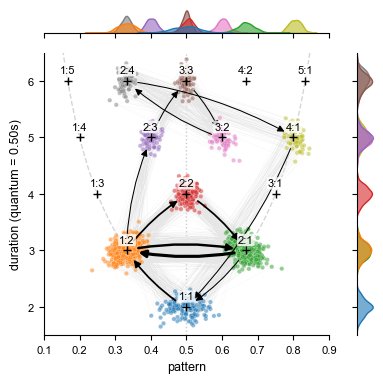

In [4]:
# Show a pattern duration plot, but now colored by label value,
# with a cluster graph on top
g = pattern_duration_plot(rs2, hue='label', 
  # palette='gist_yarg'
)
g.ax_joint.plot(rs2.patterns[:, 0], rs2.durations, c='.9', lw=0.1, zorder=-1)
set_figsize_cm(10, 10)
quantal_pattern_duration_plot(quantum=.5, ax=g.ax_joint)
show_cluster_transition_network(rs2, 'label')
g.ax_joint.set_ylim(.75, 3.25)
g.ax_joint.set_xlim(.1, .9)
g.ax_joint.legend_.remove()

plt.tight_layout()
# plt.savefig('../figures/cluster-analysis.pdf')

## 3D cluster transition network

In [5]:
import networkx as nx
from src.cluster import cluster_transition_network

In [6]:
# Use whatever clustering method to label each segment with its cluster
np.random.seed(1)
model_3d = HDBSCAN()
data = np.column_stack((rs3.patterns[:, :-1], rs3.durations))
labels = model_3d.fit_predict(data)
rs3.meta['label'] = [str(l) for l in labels]
print(f'Omitting {np.sum(labels == -1)} out of {len(labels)} unclassified segments')
subset = rs3.query('label != "-1"')

Omitting 2 out of 1498 unclassified segments


In [7]:
def bary_to_xy(ax, bary):
    # bary must be (t, l, r) with t + l + r = 1
    return tuple(ax.transProjection.transform(bary))

def show_cluster_transition_network_3d(
    rs: RhythmicSegments,
    column: str,
    ax=None,
):
    """Draw the cluster transition graph."""
    if ax is None:
        ax = plt.subplot(projection="ternary")
    graph = cluster_transition_network(rs, column=column)
    pos = nx.get_node_attributes(graph, "pos")
    pos_xy = {node: bary_to_xy(ax, [p1, p2, 1-(p1+p2)]) for node, (p1, p2, _) in pos.items()}
    edge_weights = [.5*w for w in nx.get_edge_attributes(graph, "weight").values()]

    nx.draw_networkx_edges(
        graph,
        pos_xy,
        width=edge_weights,
        arrows=True,
        arrowsize=10,
        ax=ax,
        connectionstyle="arc3,rad=-0.10",
    )
    ax.set_axis_on()
    ax.tick_params(left=True, bottom=True, labelleft=True, labelbottom=True)


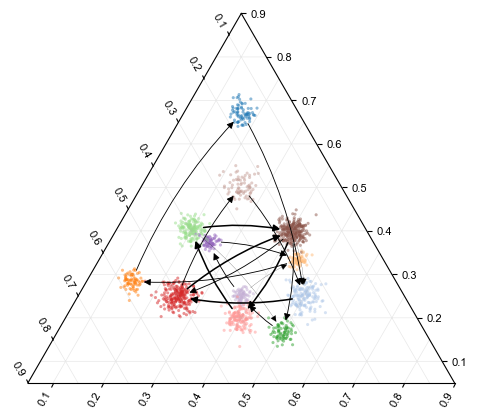

In [8]:
from mpltern.datasets import get_triangular_grid

cmap = plt.get_cmap('tab20')
colors = [cmap(int(label)) for label in subset.meta['label']]

ax = plt.subplot(projection="ternary")
top, left, right = subset.patterns.T
ax.scatter(top, left, right, c=colors, s=5, alpha=.5, lw=0)

ax.triplot(*get_triangular_grid(11), c='.7', lw=.5, alpha=0.3)
show_cluster_transition_network_3d(subset, 'label', ax=ax)
ax.set_ternary_lim(*([.05, .95]*3))

plt.savefig('../figures/cluster-analysis-3d.pdf')

## umap

In [9]:
import umap

umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, metric="euclidean", random_state=42)
embedding = umap_model.fit_transform(data)

/Users/bas/repos/papers/rsa/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/bas/repos/papers/rsa/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


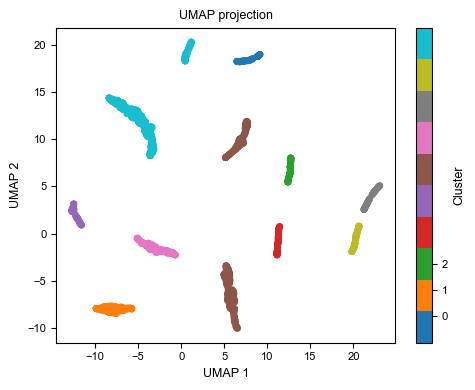

In [10]:
# Plot
plt.figure(figsize=(5, 4))
scatter = plt.scatter(embedding[:, 0], embedding[:, 1], c=labels, cmap="tab10", s=15)
plt.colorbar(scatter, ticks=[0, 1, 2], label="Cluster")
plt.title("UMAP projection")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.tight_layout()
plt.show()